# 🏥 MedGemma Differential Diagnosis System
### MultiCaRe Dataset + LangGraph

This notebook runs a structured, multi-stage diagnostic pipeline:
1. **Load Case** — patient data, imaging metadata, clinical notes
2. **Load Images** — base64 encode case images for multimodal analysis
3. **Initial Diagnosis** — MedGemma generates primary + differential diagnoses with confidence
4. **Bias Check** — identifies anchoring, availability, and other cognitive biases
5. **Alternative Hypotheses** — explores missed diagnoses and zebra conditions
6. **Final Report** — structured report with ground-truth comparison

## 1. Setup & Configuration

In [1]:
# Install dependencies
# !pip install langgraph langchain-core huggingface_hub transformers torch pillow accelerate

import os
import json
from IPython.display import display, Markdown, Image as IPImage
from pathlib import Path
import base64
from PIL import Image
import io

# ─── CONFIGURATION ─────────────────────────────────────────────────────────

# Path to your parsed MultiCaRe JSON file
os.environ['MULTICARE_DATASET_PATH'] = 'cxr_schema_dataset/dataset_per_case.json'

# Base path where images are stored
# JSON paths are like "images/filename.webp", so base path should be the parent folder
os.environ['MULTICARE_IMAGES_PATH'] = 'cxr_full_dataset'

# HuggingFace token — read from cached login, or set explicitly
_token_file = Path.home() / '.cache' / 'huggingface' / 'token'
if _token_file.exists():
    os.environ['HF_TOKEN'] = _token_file.read_text().strip()
    print(f'🔑 HF token loaded from cache ({os.environ["HF_TOKEN"][:8]}...)')
else:
    os.environ['HF_TOKEN'] = 'hf_your_token_here'
    print('⚠️  No cached token found. Set HF_TOKEN manually or run: huggingface-cli login')

# Model to use
os.environ['MEDGEMMA_MODEL'] = 'google/medgemma-1.5-4b-it'  # or google/medgemma-1.5-27b-it

# Set to '1' to use local GPU instead of HF Inference API
os.environ['USE_LOCAL_MEDGEMMA'] = '1'

print('✅ Configuration set')


🔑 HF token loaded from cache (hf_ityPh...)
✅ Configuration set


## 2. Browse Available Cases

In [2]:
dataset_path = Path(os.environ['MULTICARE_DATASET_PATH'])

with open(dataset_path) as f:
    dataset = json.load(f)

# Support list or dict
if isinstance(dataset, list):
    cases = {c['case_id']: c for c in dataset}
else:
    cases = dataset

print(f'📂 Total cases in dataset: {len(cases)}')
print()

# Show first 10 cases as a table
rows = []
for cid, c in list(cases.items())[:15]:
    patient = c.get('patient', {})
    assessment = c.get('assessment', {})
    prov = c.get('provenance', {})
    rows.append({
        'Case ID': cid[:12] + '...',
        'Age/Sex': f"{patient.get('age_years', '?')}/{patient.get('sex', '?')[0].upper()}",
        'Chief Complaint': c.get('presentation', {}).get('chief_complaint', 'N/A')[:40],
        'Primary Dx': assessment.get('diagnosis_primary', 'N/A'),
        'Images': len(c.get('images', [])),
        'Modality': c.get('study', {}).get('modality', 'N/A'),
    })

import pandas as pd
pd.set_option('display.max_colwidth', 50)
pd.DataFrame(rows)

📂 Total cases in dataset: 750



,Case ID,Age/Sex,Chief Complaint,Primary Dx,Images,Modality
0,e0a8f078-fb8...,65.0/M,Productive cough and chest pain,mucormycosis,4,CXR
1,5a336bad-577...,74.0/F,blisters on the skin and ulcers in the o,dermatitis herpetiformis,18,CXR
2,ba0d8c10-685...,53.0/F,abdominal pain and vomiting,port catheter embolization to pulmonary artery,1,CXR
3,247513aa-981...,0.0/M,"Dyspnea, cough, and sputum.",true thymic hyperplasia,4,CXR
4,d33d8d79-7fe...,48.0/F,Recurrent episodes of diffuse chest pain,sheehan syndrome,4,CXR
5,7784e783-369...,None/F,Recurrent syncope,pulmonary embolism,7,CXR
6,356f383d-391...,41.0/M,dyspnea,paragonimus kellicotti infection,4,CXR
7,fb5001b6-96f...,26.0/M,Fever and altered mental status.,tuberculous meningitis,3,CXR
8,b490fd15-9b6...,65.0/M,"dyspnea, fatigue, and bilateral pedal ed",idiopathic isolated right ventricular cardiomy...,7,CXR
9,36bf7e8e-39a...,15.0/M,Aggravated hemoptysis,anomalous origin of left pulmonary artery,4,CXR


## 3. Select a Case & Preview

In [3]:
# ─── SELECT YOUR CASE HERE ───────────────────────────────────────────────
CASE_ID = '35d90091-688c-5387-a029-82c55baa5bae'  # Change this to any case_id
# ────────────────────────────────────────────────────────────────────────

case = cases[CASE_ID]
patient = case['patient']
presentation = case['presentation']
prov = case['provenance']

display(Markdown(f"""
## 📋 Case Preview: `{CASE_ID[:16]}...`

**Source:** {prov.get('article_title', 'N/A')}

| Field | Value |
|---|---|
| Age | {patient.get('age_years', '?')} years |
| Sex | {patient.get('sex', '?')} |
| Immunocompromised | {patient.get('immunocompromised', '?')} |
| Chief Complaint | {presentation.get('chief_complaint', 'N/A')} |
| Duration | {presentation.get('symptom_duration', 'N/A')} |
| Comorbidities | {', '.join(patient.get('comorbidities', [])) or 'None'} |
| Images | {len(case.get('images', []))} |

**HPI:** {presentation.get('hpi', 'N/A')}

**Ground Truth Diagnosis:** `{case.get('assessment', {}).get('diagnosis_primary', 'N/A')}`
"""))


## 📋 Case Preview: `35d90091-688c-53...`

**Source:** Case of malignant brain edema despite successful recanalization after mechanical thrombectomy for anterior circulation stroke

| Field | Value |
|---|---|
| Age | 51.0 years |
| Sex | male |
| Immunocompromised | unknown |
| Chief Complaint | Left-sided weakness |
| Duration | 45 minutes |
| Comorbidities | atrial fibrillation |
| Images | 7 |

**HPI:** A 51-year-old man with a history of atrial fibrillation presented with acute onset of left-sided weakness 45 min after his last known well. The baseline National Institutes of Health Stroke Scale (NIHSS) score was 14, with left hemiplegia, right conjugate eye deviation, dysarthria, and facial paralysis.

**Ground Truth Diagnosis:** `malignant brain edema`


🖼️  7 images in this case:


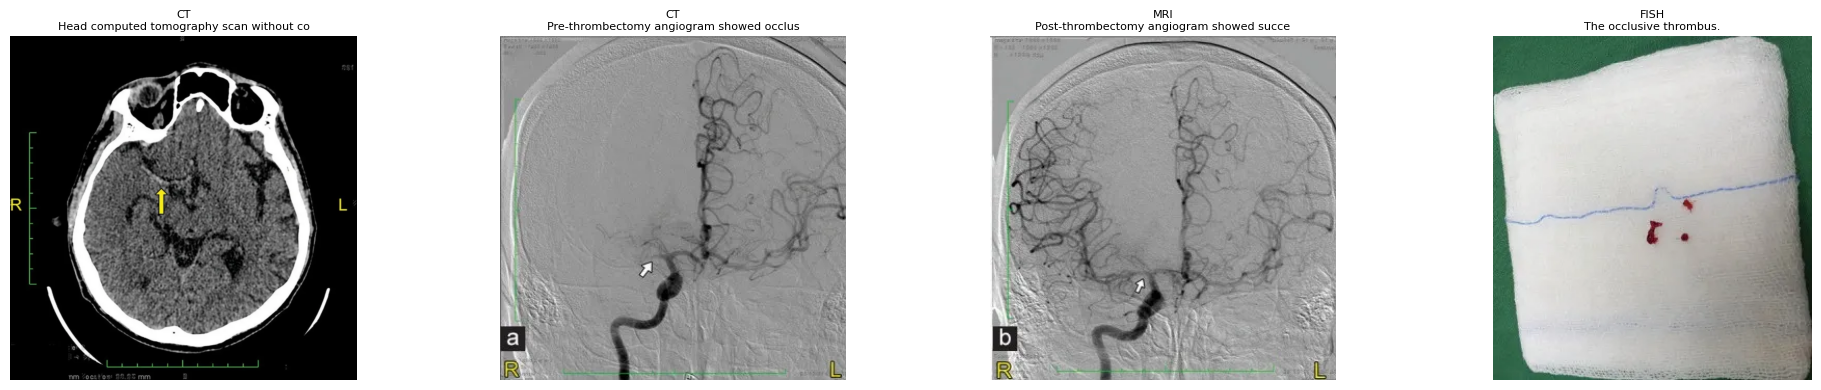

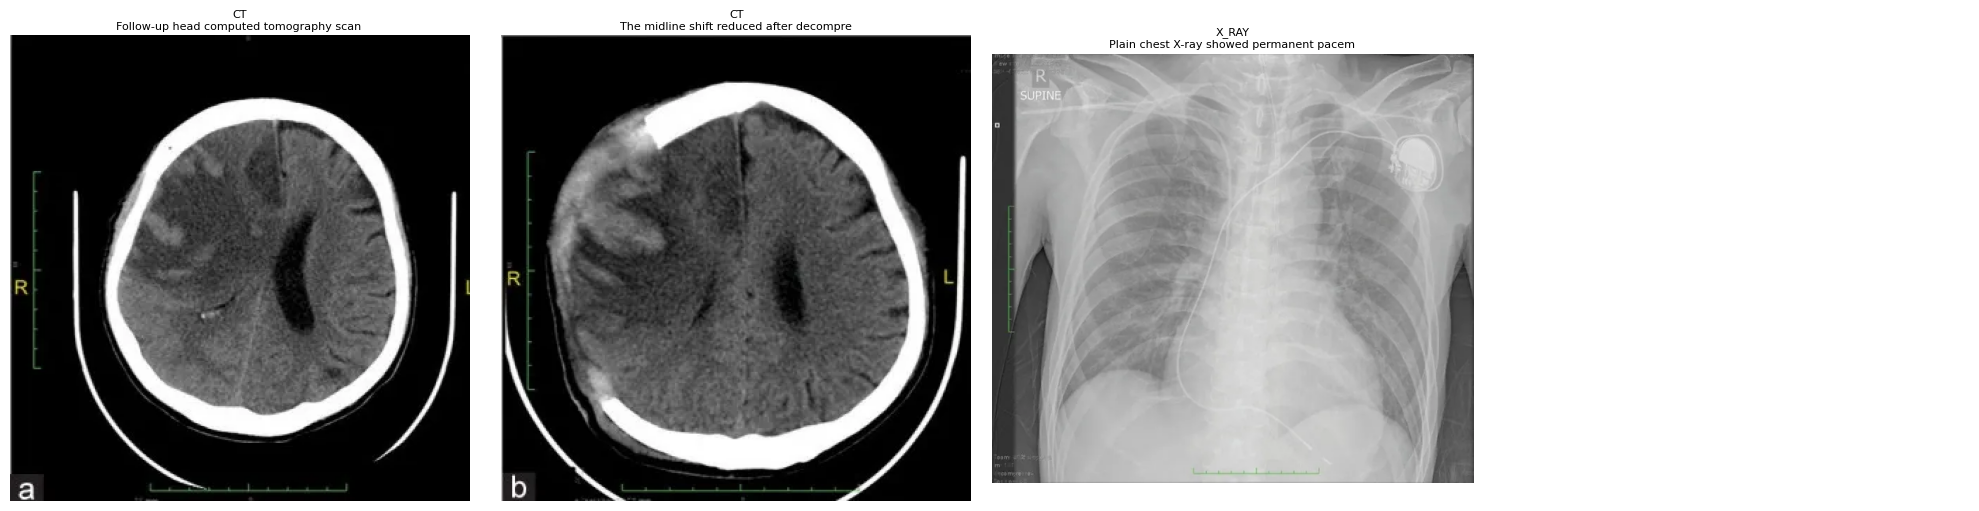

In [4]:
# Preview case images
base_path = Path(os.environ['MULTICARE_IMAGES_PATH'])
images = case.get('images', [])

print(f'🖼️  {len(images)} images in this case:')

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image as PILImage

n = len(images)
if n > 0:
    fig, axes = plt.subplots(1, min(n, 4), figsize=(5 * min(n, 4), 4))
    if n == 1:
        axes = [axes]
    
    for i, (img_meta, ax) in enumerate(zip(images[:4], axes)):
        img_path = base_path / img_meta['local_image_path']
        if img_path.exists():
            img = PILImage.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.set_title(f"{img_meta.get('image_subtype', '?').upper()}\n{img_meta.get('caption', '')[:40]}", 
                        fontsize=8, wrap=True)
        else:
            ax.text(0.5, 0.5, f'Image not found:\n{img_meta["local_image_path"]}', 
                   ha='center', va='center', transform=ax.transAxes, color='red')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Display remaining images if more than 4
if n > 4:
    fig, axes = plt.subplots((n - 4 + 3) // 4, 4, figsize=(20, 5 * ((n - 4 + 3) // 4)))
    axes = axes.flatten()
    
    for i, (img_meta, ax) in enumerate(zip(images[4:], axes)):
        img_path = base_path / img_meta['local_image_path']
        if img_path.exists():
            img = PILImage.open(img_path).convert('RGB')
            ax.imshow(img)
            ax.set_title(f"{img_meta.get('image_subtype', '?').upper()}\n{img_meta.get('caption', '')[:40]}", 
                        fontsize=8, wrap=True)
        else:
            ax.text(0.5, 0.5, f'Image not found:\n{img_meta["local_image_path"]}', 
                   ha='center', va='center', transform=ax.transAxes, color='red')
        ax.axis('off')
    
    # Hide unused subplots
    for ax in axes[n - 4:]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

## 4. Run the Full Diagnosis Pipeline

In [5]:
# Import the graph
import sys
sys.path.insert(0, '.')  # Ensure local module is importable

from diagnosis_graph import build_diagnosis_graph, DiagnosisState, preload_model

print('✅ Diagnosis graph imported')


✅ Diagnosis graph imported


In [6]:
# Pre-load the model into GPU memory so the pipeline doesn't stall on first call.
# Run this cell once — subsequent pipeline runs will reuse the cached weights.
from diagnosis_graph import preload_model
preload_model()


2026-02-20 15:44:08.269892: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-20 15:44:08.306612: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 15:44:10.067762: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[medgemma] Loading local model: google/medgemma-1.5-4b-it  (this may take a minute)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[medgemma] Model loaded.
[preload] Model ready: google/medgemma-1.5-4b-it


In [7]:
# GPU status check — run before the pipeline to confirm GPU is active
import torch

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_name(i)
        total = torch.cuda.get_device_properties(i).total_memory / 1024**3
        used  = torch.cuda.memory_allocated(i) / 1024**3
        reserved = torch.cuda.memory_reserved(i) / 1024**3
        print(f'GPU {i}: {name}')
        print(f'  Total VRAM : {total:.1f} GB')
        print(f'  Allocated  : {used:.2f} GB  (rises to ~8 GB after model loads)')
        print(f'  Reserved   : {reserved:.2f} GB')
        print(f'  Free       : {total - reserved:.2f} GB')
else:
    print('⚠️  No CUDA GPU detected — inference will run on CPU (very slow)')


GPU 0: NVIDIA L4
  Total VRAM : 22.0 GB
  Allocated  : 8.02 GB  (rises to ~8 GB after model loads)
  Reserved   : 8.03 GB
  Free       : 14.01 GB


In [8]:
# Run the pipeline
graph = build_diagnosis_graph()

initial_state: DiagnosisState = {
    'case_id': CASE_ID,
    'case_data': {},
    'images_b64': [],
    'initial_diagnosis': None,
    'differential_diagnoses': None,
    'bias_check_notes': None,
    'alternative_hypotheses': None,
    'final_report': None,
    'messages': [],
}

print('🔄 Running diagnosis pipeline...')
print('   Nodes: load_case → load_images → initial_diagnosis → bias_check → alternative_hypotheses → final_report')
print()

final_state = graph.invoke(initial_state)

print('\n✅ Pipeline complete!')

🔄 Running diagnosis pipeline...
   Nodes: load_case → load_images → initial_diagnosis → bias_check → alternative_hypotheses → final_report



[load_case] Loaded case: Case of malignant brain edema despite successful recanalization after mechanical thrombectomy for anterior circulation stroke
[load_images] Loaded image: ct (cea55e05...)
[load_images] Loaded image: ct (d34fec5a...)
[load_images] Loaded image: mri (b959d207...)
[load_images] Loaded image: fish (b619a865...)
[load_images] Loaded image: ct (c149686d...)
[load_images] Loaded image: ct (afc68b98...)
[load_images] Loaded image: x_ray (3c3c1b07...)
[diagnosis] Generating initial diagnosis...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[diagnosis] Attempt 1 - Raw response (6169 chars):
FINDINGS:
- The patient presents with acute onset left-sided weakness, consistent with an acute ischemic stroke.
- The patient has a history of atrial fibrillation and was not anticoagulated, which is a significant risk factor for cardioembolic stroke.
- The initial NIHSS score was 14, indicating a moderate stroke.
- The CT head without contrast showed a hyperdense right MCA sign, suggestive of an acute ischemic stroke.
- The CTA angiogram confirmed occlusion of the right MCA with no collateral 
... (5669 more chars)
[diagnosis] JSON extraction successful on attempt 1
[bias_check] Performing cognitive bias check...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[bias_check] Response (5108 chars)
[alternatives] Generating alternative hypotheses...
[alternatives] Raw response (4533 chars):
FINDINGS:
- The patient is intubated with an endotracheal tube (ETT) in place.
- A temporary pacemaker is present.
- A permanent pacemaker is present.
- A right-sided central venous catheter is present.
- The chest X-ray shows no acute cardiopulmonary abnormalities.

IMPRESSION:
- Intubated patient with ETT, temporary pacemaker, permanent pacemaker, and right central venous catheter.
- No acute cardiopulmonary abnormalities on chest X-ray.

```json
[
  {"condition": "Malignant Brain Edema with S
... (4033 more chars)
[report] Compiling final diagnostic report...

✅ Pipeline complete!


## 5. View Results

In [9]:
# Primary Diagnosis
print('=== PRIMARY DIAGNOSIS ===')
try:
    diag = json.loads(final_state['initial_diagnosis'])
    # Support both acute_complication (new schema) and primary_diagnosis (legacy)
    primary = diag.get('acute_complication', diag.get('primary_diagnosis', diag.get('underlying_etiology', {})))
    print(f"Condition:   {primary.get('condition', 'N/A')}")
    print(f"Confidence:  {primary.get('confidence', '?')}%")
    print(f"Reasoning:   {primary.get('reasoning', 'N/A')}")
    
    # Also show underlying etiology if different
    etiology = diag.get('underlying_etiology', {})
    if etiology.get('condition') and etiology.get('condition') != primary.get('condition'):
        print(f"\n=== UNDERLYING ETIOLOGY ===")
        print(f"Condition:   {etiology.get('condition', 'N/A')}")
        print(f"Confidence:  {etiology.get('confidence', '?')}%")
except:
    print(final_state['initial_diagnosis'])

=== PRIMARY DIAGNOSIS ===
Condition:   Malignant Brain Edema with Significant Midline Shift
Confidence:  90%
Reasoning:   The follow-up CT scan shows significant brain swelling (edema) and mass effect (midline shift) in the right hemisphere, a severe complication of ischemic stroke that requires urgent management, such as decompressive craniectomy.

=== UNDERLYING ETIOLOGY ===
Condition:   Cardioembolic Stroke
Confidence:  95%


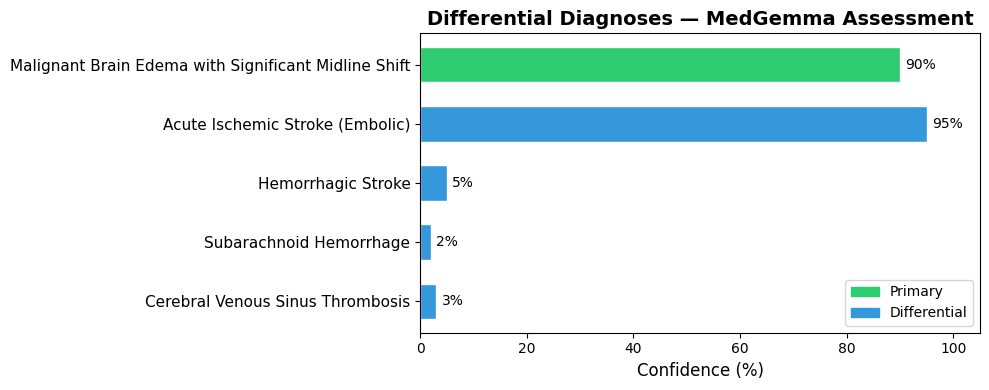

In [10]:
# Differential Diagnoses - Visualization
import matplotlib.pyplot as plt
import numpy as np

differentials = final_state.get('differential_diagnoses', [])

if differentials and isinstance(differentials[0], dict) and 'condition' in differentials[0]:
    conditions = [d.get('condition', 'Unknown') for d in differentials]
    confidences = [d.get('confidence', 0) for d in differentials]
    
    # Add primary - support both acute_complication (new schema) and primary_diagnosis (legacy)
    try:
        diag_data = json.loads(final_state['initial_diagnosis'])
        primary = diag_data.get('acute_complication', diag_data.get('primary_diagnosis', diag_data.get('underlying_etiology', {})))
        if primary.get('condition'):
            conditions = [primary.get('condition', 'Primary')] + conditions
            confidences = [primary.get('confidence', 0)] + confidences
    except:
        pass
    
    colors = ['#2ecc71'] + ['#3498db'] * (len(conditions) - 1)
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(conditions) * 0.8)))
    bars = ax.barh(range(len(conditions)), confidences, color=colors, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(conditions)))
    ax.set_yticklabels(conditions, fontsize=11)
    ax.set_xlabel('Confidence (%)', fontsize=12)
    ax.set_title('Differential Diagnoses — MedGemma Assessment', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.invert_yaxis()
    
    for bar, conf in zip(bars, confidences):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{conf}%', va='center', fontsize=10)
    
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#2ecc71', label='Primary'), Patch(color='#3498db', label='Differential')],
             loc='lower right')
    
    plt.tight_layout()
    plt.show()
else:
    print("No differentials with valid structure found. Raw data:")
    print(differentials)

In [11]:
# Bias Check
print('=== COGNITIVE BIAS ANALYSIS ===')
print(final_state.get('bias_check_notes', 'N/A'))

=== COGNITIVE BIAS ANALYSIS ===
Okay, let's perform a cognitive bias audit on the initial diagnosis and reasoning provided.

**1. ANCHORING BIAS:**

*   **What it is:** The tendency to rely too heavily on the first piece of information encountered (the initial presentation and history) when making subsequent judgments.
*   **How it might be skewing the diagnosis:** The initial presentation strongly points towards an ischemic stroke, specifically a cardioembolic one due to the AF history. The initial CT finding of a hyperdense MCA sign further supports this. The subsequent finding of malignant edema and midline shift, while severe, is a known complication of ischemic stroke. The anchoring bias might make the clinician overly focused on the *initial* diagnosis of ischemic stroke and its likely cardioembolic source, potentially overlooking other possibilities that might present similarly or be exacerbated by the initial stroke.
*   **What to reconsider:** While the initial diagnosis is hi

In [12]:
# Alternative Hypotheses
print('=== MISSED / ALTERNATIVE DIAGNOSES ===')
alts = final_state.get('alternative_hypotheses', [])

for i, alt in enumerate(alts, 1):
    if isinstance(alt, dict) and 'condition' in alt:
        risk = alt.get('risk_if_missed', '?').upper()
        risk_colors = {'CRITICAL': '🔴', 'HIGH': '🟠', 'MEDIUM': '🟡', 'LOW': '🟢'}
        icon = risk_colors.get(risk, '⚪')
        print(f"\n{icon} [{i}] {alt['condition']} (Risk: {risk}, Confidence: {alt.get('confidence', '?')}%)")
        print(f"   Why missed:    {alt.get('why_missed', 'N/A')}")
        print(f"   Evidence:      {'; '.join(alt.get('supporting_evidence', [])[:2])}")
        print(f"   Confirm via:   {'; '.join(alt.get('confirmatory_tests', [])[:3])}")

=== MISSED / ALTERNATIVE DIAGNOSES ===

🔴 [1] Malignant Brain Edema with Significant Midline Shift (Risk: CRITICAL, Confidence: 95%)
   Why missed:    The initial presentation focused on the acute stroke symptoms, and the follow-up CT revealed the severe complication. The severity of the edema and midline shift might be initially underestimated or attributed solely to the stroke itself, especially if the focus was on the recanalization.
   Evidence:      Follow-up head CT scan showing malignant brain edema with significant midline shift on the right hemisphere.; Clinical presentation of acute left-sided weakness and focal neurological deficits.
   Confirm via:   Follow-up head CT scan; Clinical examination for neurological deficits and signs of increased intracranial pressure.

🔴 [2] Subdural Hematoma (Risk: CRITICAL, Confidence: 70%)
   Why missed:    While the follow-up CT shows edema, it doesn't explicitly mention hemorrhage. However, severe edema can sometimes be associated with or

In [13]:
# Full Report
print(final_state['final_report'])


╔══════════════════════════════════════════════════════════════════════╗
║           MEDGEMMA DIFFERENTIAL DIAGNOSIS REPORT                    ║
╚══════════════════════════════════════════════════════════════════════╝

CASE ID: 35d90091-688c-5387-a029-82c55baa5bae
SOURCE:  Case of malignant brain edema despite successful recanalization after mechanical thrombectomy for anterior circulation stroke (Surg Neurol Int, 2023)
PMC ID:  PMC10159319

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PATIENT SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
51-year-old man with atrial fibrillation presented with acute onset of left-sided weakness due to right MCA occlusion. He underwent thrombectomy but developed malignant brain edema requiring decompressive craniectomy.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PRIMARY DIAGNOSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Condition:   Malignant B

## 6. Save Results

In [14]:
output = {
    'case_id': final_state['case_id'],
    'primary_diagnosis': json.loads(final_state.get('initial_diagnosis', '{}')),
    'differentials': final_state.get('differential_diagnoses', []),
    'bias_analysis': final_state.get('bias_check_notes', ''),
    'alternative_hypotheses': final_state.get('alternative_hypotheses', []),
    'report': final_state.get('final_report', ''),
    'ground_truth': final_state['case_data'].get('assessment', {}),
}

out_path = f'diagnosis_{CASE_ID[:8]}.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2, default=str)

print(f'✅ Results saved to {out_path}')

✅ Results saved to diagnosis_35d90091.json


## 7. Ranked Diagnosis List

View all diagnoses ranked by confidence — primary, differentials, and alternative hypotheses.

In [15]:
# Create chat session and display ranked diagnoses
from diagnosis_graph import create_chat_session

chat = create_chat_session(final_state)
summary = chat.get_diagnosis_summary()

# Display ranked list
print("=" * 70)
print("🏥 RANKED DIAGNOSIS LIST")
print("=" * 70)
print(f"\n🎯 GROUND TRUTH: {summary['ground_truth']}\n")
print("-" * 70)

for dx in summary['ranked_list']:
    rank = dx['rank']
    conf = dx['confidence']
    cond = dx['condition']
    dtype = dx['type']
    
    # Color/icon by type
    if dtype == 'primary':
        icon = '🥇'
        label = 'PRIMARY'
    elif dtype == 'differential':
        icon = '🔹'
        label = 'DIFFERENTIAL'
    else:
        icon = '⚠️'
        risk = dx.get('risk_if_missed', '?').upper()
        label = f'ALTERNATIVE (Risk: {risk})'
    
    # Confidence bar
    bar_len = int(conf / 5)  # Scale to 20 chars
    bar = '█' * bar_len + '░' * (20 - bar_len)
    
    print(f"\n{icon} #{rank} {cond}")
    print(f"   {label} | Confidence: {conf}%")
    print(f"   [{bar}]")
    if dx.get('reasoning'):
        print(f"   💡 {dx['reasoning'][:100]}...")

print("\n" + "=" * 70)
print(f"Total diagnoses considered: {len(summary['ranked_list'])}")


🏥 RANKED DIAGNOSIS LIST

🎯 GROUND TRUTH: malignant brain edema

----------------------------------------------------------------------

🥇 #1 Malignant Brain Edema with Significant Midline Shift
   PRIMARY | Confidence: 90%
   [██████████████████░░]
   💡 The follow-up CT scan shows significant brain swelling (edema) and mass effect (midline shift) in th...

🔹 #2 Acute Ischemic Stroke (Embolic)
   DIFFERENTIAL | Confidence: 95%
   [███████████████████░]
   💡 History of atrial fibrillation without anticoagulation; Acute onset of focal neurological deficits (...

🔹 #3 Hemorrhagic Stroke
   DIFFERENTIAL | Confidence: 5%
   [█░░░░░░░░░░░░░░░░░░░]

🔹 #4 Subarachnoid Hemorrhage
   DIFFERENTIAL | Confidence: 2%
   [░░░░░░░░░░░░░░░░░░░░]

🔹 #5 Cerebral Venous Sinus Thrombosis
   DIFFERENTIAL | Confidence: 3%
   [░░░░░░░░░░░░░░░░░░░░]

⚠️ #6 Malignant Brain Edema with Significant Midline Shift
   ALTERNATIVE (Risk: CRITICAL) | Confidence: 95%
   [███████████████████░]
   💡 The initial presentatio

## 8. Interactive Chat with Case Context

Ask follow-up questions about the patient case. The AI has access to all patient data, images, and the diagnosis results as context.

In [16]:
# ─── ASK A QUESTION ────────────────────────────────────────────────────
# Change the question below and re-run this cell to chat with the case

QUESTION = "What imaging findings support the primary diagnosis?"
QUESTION = "Is your primary diagnosis consistent with the patient's ground truth?"
# Set to True if your question is about the radiological images
INCLUDE_IMAGES = False
chat.clear_history()
# ────────────────────────────────────────────────────────────────────────

print(f"💬 You: {QUESTION}\n")
print("-" * 60)

response = chat.ask(QUESTION, include_images=INCLUDE_IMAGES)

print(f"\n🤖 MedGemma:\n{response}")
print("\n" + "-" * 60)
print(f"💡 Conversation turns: {len(chat.history) // 2}")


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Chat history cleared.
💬 You: Is your primary diagnosis consistent with the patient's ground truth?

------------------------------------------------------------

🤖 MedGemma:
Yes, the primary diagnosis of "Cardioembolic Stroke" is consistent with the patient's ground truth of "malignant brain edema". The patient's history of atrial fibrillation is a major risk factor for cardioembolic stroke, which is the underlying etiology of the ischemic event that led to the malignant brain edema. The clinical presentation and imaging findings (hyperdense MCA sign, MCA occlusion, subsequent edema and midline shift) are all consistent with a cardioembolic ischemic stroke complicated by malignant brain edema.


------------------------------------------------------------
💡 Conversation turns: 1


In [17]:
# Example questions to try (copy one to the cell above and re-run):
example_questions = [
    "Why did you choose this as the primary diagnosis over the alternatives?",
    "What tests would you order to confirm or rule out this diagnosis?",
    "What are the key risk factors in this patient's history?",
    "Could this be an atypical presentation of tuberculosis?",
    "What is the prognosis for this condition?",
    "What treatment would you recommend?",
    "Are there any findings that argue against your diagnosis?",
    "What would you expect to see on follow-up imaging?",
]

print("📝 Example questions to ask:\n")
for i, q in enumerate(example_questions, 1):
    print(f"  {i}. {q}")


📝 Example questions to ask:

  1. Why did you choose this as the primary diagnosis over the alternatives?
  2. What tests would you order to confirm or rule out this diagnosis?
  3. What are the key risk factors in this patient's history?
  4. Could this be an atypical presentation of tuberculosis?
  5. What is the prognosis for this condition?
  6. What treatment would you recommend?
  7. Are there any findings that argue against your diagnosis?
  8. What would you expect to see on follow-up imaging?


In [18]:
# View conversation history
print("📜 Conversation History")
print("=" * 60)

if not chat.history:
    print("No conversation yet. Ask a question above!")
else:
    for i, turn in enumerate(chat.history):
        role = "You" if turn["role"] == "user" else "MedGemma"
        icon = "💬" if turn["role"] == "user" else "🤖"
        content = turn["content"][:200] + "..." if len(turn["content"]) > 200 else turn["content"]
        print(f"\n{icon} {role}:\n{content}")
    
    print("\n" + "=" * 60)
    print(f"Total turns: {len(chat.history) // 2}")
    print("\n# To clear history, run: chat.clear_history()")


📜 Conversation History

💬 You:
Is your primary diagnosis consistent with the patient's ground truth?

🤖 MedGemma:
Yes, the primary diagnosis of "Cardioembolic Stroke" is consistent with the patient's ground truth of "malignant brain edema". The patient's history of atrial fibrillation is a major risk factor for c...

Total turns: 1

# To clear history, run: chat.clear_history()
